In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math


# Partie 1

In [6]:
def Rp(R,A):
    return A*R/(1-A)

def Rp_bis(Qint, omega0, C=10*1E-9):
    return Qint/(C*omega0)

def Q_int(Q,R,omega0, C=10*1E-9):
    Q_ext = R*C*omega0
    return 1/(1/Q - 1/Q_ext)

## R = 47 kOhm

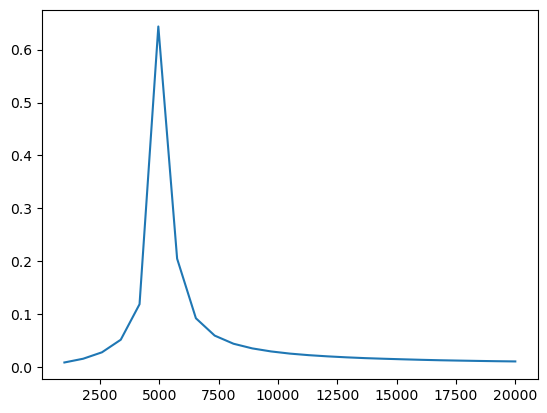

In [7]:
freq = pd.read_csv('Bode_47.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_47.csv')[' Amplitude [dB]']

amp = 10**(gain/20)
plt.plot(freq, amp)
plt.show()

fréquence de résonance 5136.417462749999
facteur de qualité 163.10267660168213
Rp -54296.38098616641
Rp 43000.96543210806
Q_int 13.877728549911204
Valeur attendue de Qext 15.16833948474098


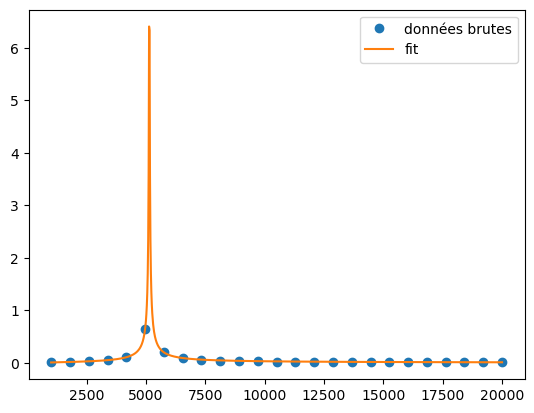

In [11]:

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()

R = 47*1E3
p0 = (5000, 0.6, 1000)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
nu0, A, Q = popt


plt.plot(freq_np, amp_np, 'o', label ='données brutes')
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
plt.plot(freq_np, model(freq_np, *popt), label = "fit")
plt.legend()
print('fréquence de résonance', nu0)
print('facteur de qualité', abs(Q))
print('Rp', Rp(R,A))
omega0 = nu0*2*np.pi
print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print('Q_int', abs(Q_int(Q, R,omega0)) )
print('Valeur attendue de Qext', R*10*1E-9*omega0 )
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))

Fit results (units: f0 in Hz):
f0 = 5136.417 Hz ± 10.665
A  = 7.43876 ± 72.42228
Q_loaded = 163.041 ± 1589.873

Derived quantities (use omega0 = 2π f0):
omega0 = 32273.060 rad/s
Q_int = 16.724
Rp (from Q_int) = 51.82 kΩ
Loss 0.5243930916447495


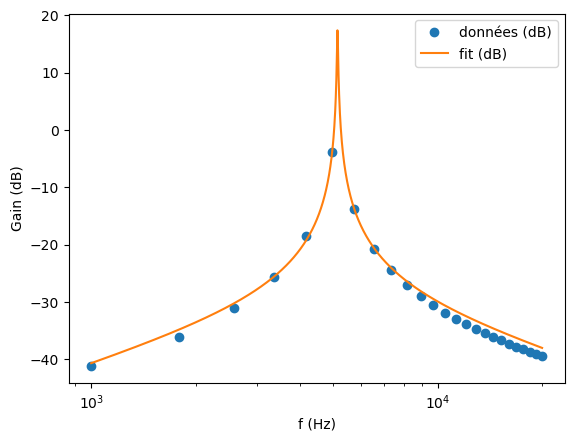

5032.921210448703


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

C = 10e-9  # F
R = 47
L = 100e-3
file = 'Bode_47.csv'

def model(f, f0, A, Q):
    return A / np.sqrt(1 + Q**2 * (f/f0 - f0/f)**2)

def Qint(Q, R, f0, C=C):
    omega0 = 2*np.pi*f0
    Q_ext = R * C * omega0
    return 1/ (1/Q_loaded - 1/Q_ext)

def Rp(Qint, f0, C=C):
    omega0 = 2*np.pi*f0
    return Qint / (C * omega0)

def pertes(Rp, R):
    return Rp/(R+Rp)

df = pd.read_csv(file)
freq = df['Frequency [Hz]'].to_numpy()
gain_db = df[' Amplitude [dB]'].to_numpy()  
amp = 10**(gain_db / 20.0)  

p0 = (np.mean(freq), np.max(amp), 50.0) 
bounds = ([0, 0, 1e-1], [np.max(freq)*2, 10.0, 1e4])  

popt, pcov = curve_fit(model, freq, amp, p0=p0, bounds=bounds, maxfev=20000)
f0_fit, A_fit, Q_fit = popt
perr = np.sqrt(np.diag(pcov))

omega0 = 2*np.pi*f0_fit
Q_loaded = abs(Q_fit)
Q_int = abs(Qint(Q_loaded, 47*10**3, f0=f0_fit))  
Rp = Rp(Q_int, f0_fit)


print("Fit results (units: f0 in Hz):")
print(f"f0 = {f0_fit:.3f} Hz ± {perr[0]:.3f}")
print(f"A  = {A_fit:.5f} ± {perr[1]:.5f}")
print(f"Q_loaded = {Q_loaded:.3f} ± {perr[2]:.3f}")
print()
print("Derived quantities (use omega0 = 2π f0):")
print(f"omega0 = {omega0:.3f} rad/s")
print(f"Q_int = {Q_int:.3f}")
print(f"Rp (from Q_int) = {Rp/1e3:.2f} kΩ")
print(f"Loss {pertes(Rp/1e3, R)}")

# tracer
f_fine = np.linspace(np.min(freq), np.max(freq), 2000)
plt.figure()
plt.semilogx(freq, gain_db, 'o', label='données (dB)')
plt.semilogx(f_fine, 20*np.log10(model(f_fine, *popt)), label='fit (dB)')
plt.xlabel('f (Hz)')
plt.ylabel('Gain (dB)')
plt.legend()
plt.show()
print(1/np.sqrt(L*C)/(2*np.pi))

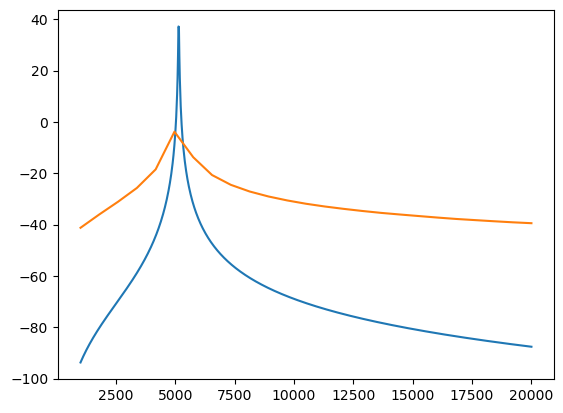

In [61]:
G_fit = 20*np.log(model(freq_np, *popt))
G_brut = gain

plt.plot(freq_np, G_fit)
plt.plot(freq, G_brut)

## R = 100 kOhm

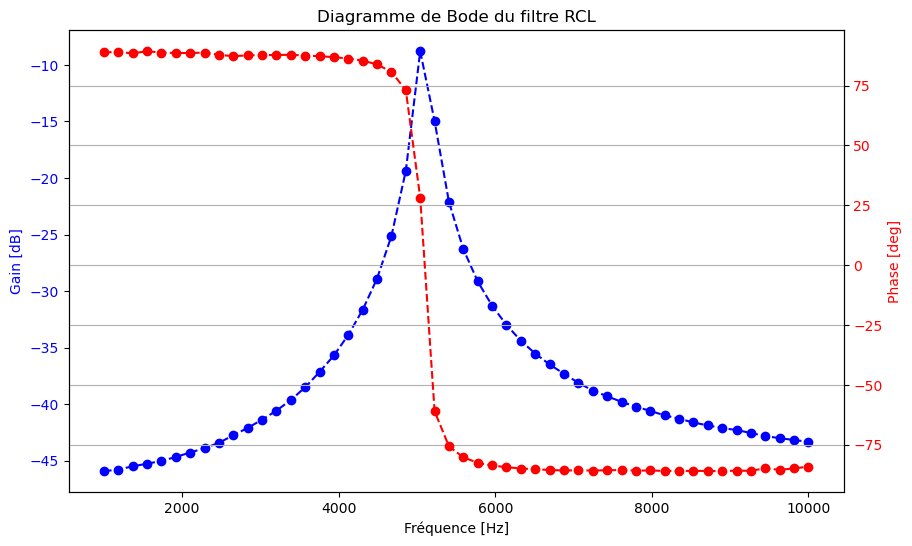

In [68]:
freq = pd.read_csv('Bode_100.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_100.csv')[' Amplitude [dB]']
phase = pd.read_csv('Bode_100.csv')[' Phase [deg]']


amp = 10**(gain/20)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot California sales
plt.plot(freq, gain, marker ='o', linestyle ='--', color ='b', label ='Gain')
ax1.set_xlabel('Fréquence [Hz]')
ax1.set_ylabel('Gain [dB]', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second Y-axis sharing the same X-axis
ax2 = ax1.twinx()

# Plot Texas sales
plt.plot(freq, phase, marker ='o', linestyle = '--', color ='r', label ='phase')
ax2.set_ylabel('Phase [deg]', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Add title and legend
plt.title("Diagramme de Bode du filtre RCL")
plt.grid(which='both')
plt.show()

fréquence de résonance 31992.532594988243
facteur de qualité 58.94330283638724
Rp 60932.6233538775
Rp 37447.18814592049
Q_int 11.980303873490184
Valeur attendue de Quint 15.036490319644475
[5090.09009009]
50


<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
C:\Users\jolet\AppData\Local\Temp\ipykernel_2728\3818731876.py:31: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$H( \omega )$')
C:\Users\jolet\AppData\Local\Temp\ipykernel_2728\3818731876.py:32: SyntaxWarning: invalid escape sequence '\o'
  plt.title('Amplitude de la fonction de transfert $H(\omega)$ en fonction de la fréquence')


Text(0.5, 1.0, 'Amplitude de la fonction de transfert $H(\\omega)$ en fonction de la fréquence')

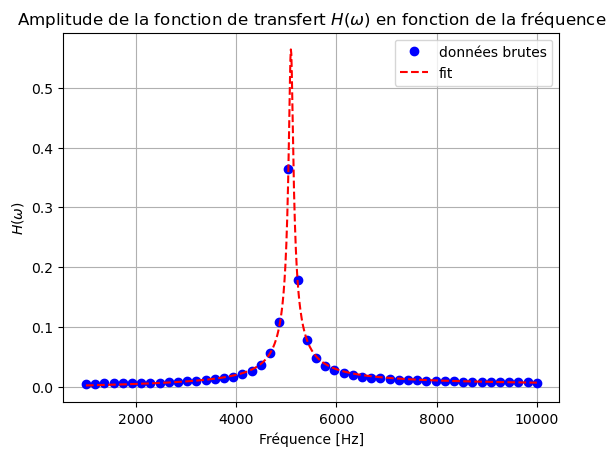

In [63]:

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()


p0 = (5000, 0.6, 1000)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi

plt.plot(freq_np, amp_np, 'o', label ='données brutes', color ='b')
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
plt.plot(freq_np, model(freq_np, *popt), label = "fit", linestyle ='--', color ='r')
plt.legend()

print('fréquence de résonance', omega0)
print('facteur de qualité', abs(Q))
print('Rp', Rp(R,A))
print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print('Q_int', abs(Q_int(Q, R,omega0)) )
print('Valeur attendue de Quint', R*10*1E-9*omega0 )
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
print(freq_np[mask])
print(len(amp_np))
plt.grid()
plt.xlabel('Fréquence [Hz]')
plt.ylabel('$H( \omega )$')
plt.title('Amplitude de la fonction de transfert $H(\omega)$ en fonction de la fréquence')


## R = 100 kOhm (bis)


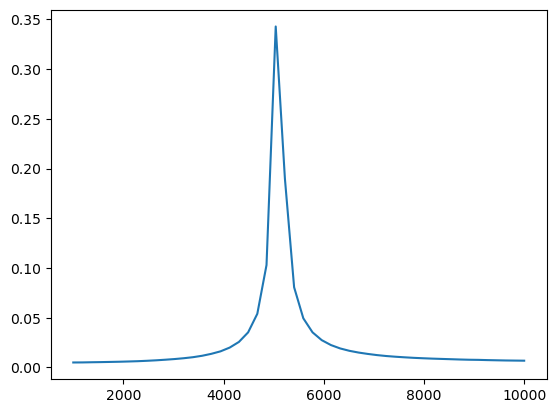

In [64]:
freq = pd.read_csv('Bode_100_bis.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_100_bis.csv')[' Amplitude [dB]']

amp = 10**(gain/20)
plt.plot(freq, amp)
plt.show()

fréquence de résonance 32046.566672104243
facteur de qualité 69.02575728678396
Rp 88736.46397023537
Rp 38581.299852289994
Q_int 12.36398198012857
Valeur attendue de Quint 15.061886335888996
[5099.0990991]
50


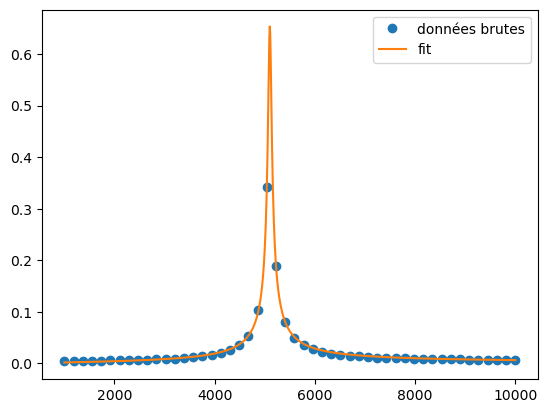

In [65]:

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()


p0 = (5000, 0.6, 1000)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi

plt.plot(freq_np, amp_np, 'o', label ='données brutes')
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
plt.plot(freq_np, model(freq_np, *popt), label = "fit")
plt.legend()

print('fréquence de résonance', omega0)
print('facteur de qualité', abs(Q))
print('Rp', Rp(R,A))
print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print('Q_int', abs(Q_int(Q, R,omega0)) )
print('Valeur attendue de Quint', R*10*1E-9*omega0 )
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
print(freq_np[mask])
print(len(amp_np))


## R = 218 kOhm

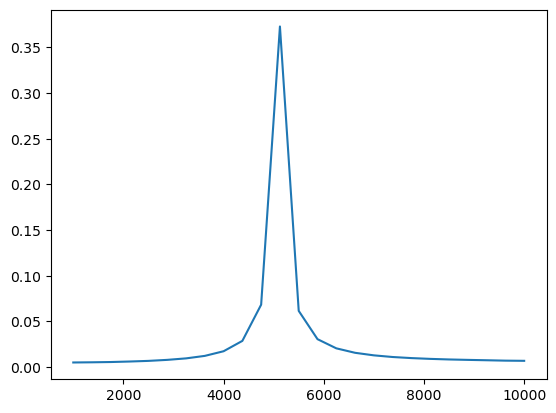

In [66]:
freq = pd.read_csv('Bode_278.csv')['Frequency [Hz]']
gain = pd.read_csv('Bode_278.csv')[' Amplitude [dB]']

amp = 10**(gain/20)
plt.plot(freq, amp)
plt.show()

Pulsation de résonance 31965.560779347306
facteur de qualité 49.737752848032855
Rp 40368.87814852261
Rp 67341.08638276088
Q_int 21.5259558971542
Valeur attendue de Qext 15.023813566293235
[5090.09009009]


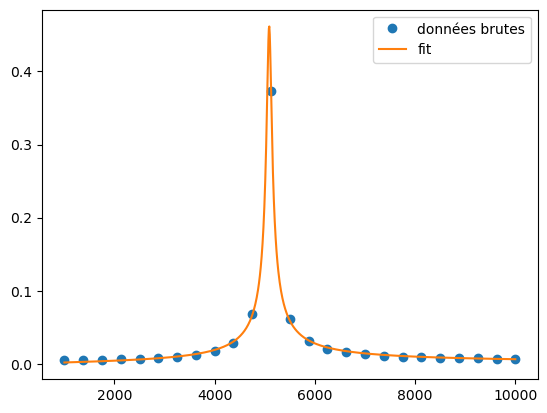

In [67]:

def model(w, w0, A, Q):                                    
    return A/np.sqrt((1+Q**2*(w/w0 - w0/w)**2))
    
freq_np = freq.to_numpy()
amp_np = amp.to_numpy()


p0 = (5000, 0.6, 1000)

popt, pcov = curve_fit(model, freq_np, amp_np, p0)
omega0, A, Q = popt
omega0 = omega0*2*np.pi


plt.plot(freq_np, amp_np, 'o', label ='données brutes')
freq_np = np.linspace(np.min(freq_np), np.max(freq_np), 1000)
#plt.plot(freq_np, model(freq_np, *p0), label = "à l'oeil")
plt.plot(freq_np, model(freq_np, *popt), label = "fit")
plt.legend()

print('Pulsation de résonance', omega0)
print('facteur de qualité', abs(Q))
print('Rp', Rp(R,A))
print('Rp', Rp_bis(abs(Q_int(Q, R,omega0)), omega0 ))
print('Q_int', abs(Q_int(Q, R,omega0)) )
print('Valeur attendue de Qext', R*10*1E-9*omega0 )
mask = model(freq_np, *popt) == np.max(model(freq_np, *popt))
print(freq_np[mask])

# Partie 4 - Démarage des oscillations


Gain au démarrage des oscillations :

In [54]:
R2 = 2E3
R1 = 1.8E3
G_dem = 1+R2/R1
print("Gain au démarrage des oscillations", 1 + R2/R1)

Gain au démarrage des oscillations 2.111111111111111


On a que $|H(\omega_0)| = \frac{R_p}{R+R_p}$.

Critère de Barkhausen : condition nécessaire pour qu'un circuit constitué d'un amplificateur et d'une boucle de contre-réaction se mette à osciller. La conditin sur l'amplitude dit que le gain de contre-réaction est de , c'est à dire $|H(\omega) G| = 1 = G |H(\omega)|$. Donc à la fréquence de résonance $\omega_0$, on a  $G \frac{R_p}{R+R_p} = 1$
Donc au démarage des oscillations, $$G = \frac{R_p + R}{R_p}$$

On en déduit les pertes en prenant $$1/G$$

In [60]:
1/G_dem

0.47368421052631576

$ G \cdot \frac{Rp}{R + Rp} - 1 = 1 $ pour $$G = \frac{2(R+R_p)}{R_p}$$ et donc ?
 
On est 2 fois au dessus du seuil des oscillations. On se place sur ce gain. Alors $$\alpha = \frac{\omega_0}{2Q}$$


In [67]:
pd.read_csv('scopeData(23).csv')

,TIME ms,IN2
0,5.000,0.004799
1,4.990,-0.002525
2,4.980,-0.011314
3,4.971,-0.021568
4,4.961,-0.032066
...,...,...
1019,-4.951,-1.271568
1020,-4.961,-1.534508
1021,-4.971,-1.739830
1022,-4.980,-1.667320


In [210]:
time = pd.read_csv('scopeData(23).csv')['TIME ms']*1E-3
Vin = pd.read_csv('scopeData(23).csv')[' IN2']
time = time.to_numpy()
Vin = Vin.to_numpy()
time_cropped, Vin_cropped = time[150:500], Vin[150:500]

In [211]:
def model(t, A, alpha, omega, phi):
    return A*np.exp(alpha*t)*np.cos(omega*t + phi)

p0 = (0.3, 800, 30, 0)

popt, pcov = curve_fit(model, time_cropped, Vin_cropped, p0)
A, alpha, omega, phi = popt
perr = np.sqrt(np.diag(pcov))
u_alpha = perr[2]

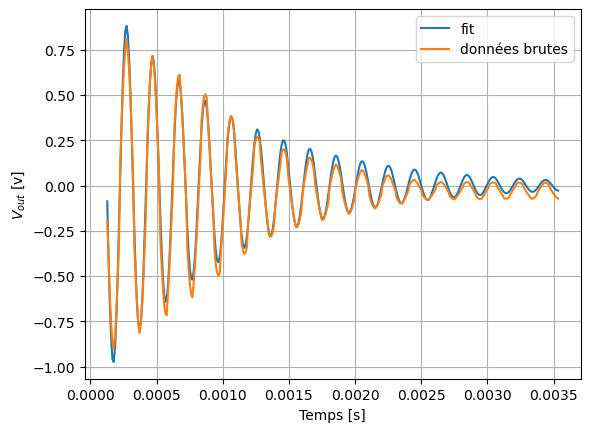

In [212]:
#plt.plot(time_cropped, model(time_cropped, *p0))
plt.plot(time_cropped, model(time_cropped, *popt), label ='fit')
plt.plot(time_cropped, Vin_cropped, label = 'données brutes')
plt.legend()
plt.xlabel("Temps [s]")
plt.ylabel("$V_{out}$ [v]")
plt.grid()
plt.show()

In [213]:
print(f"{alpha} +/- {u_alpha}")

-1054.6067100928115 +/- 17.149158190733843


In [214]:
Q = -1/(np.sqrt(L*C)*2*alpha)
print(Q)

14.992686988925382


Avec find peaks plutot

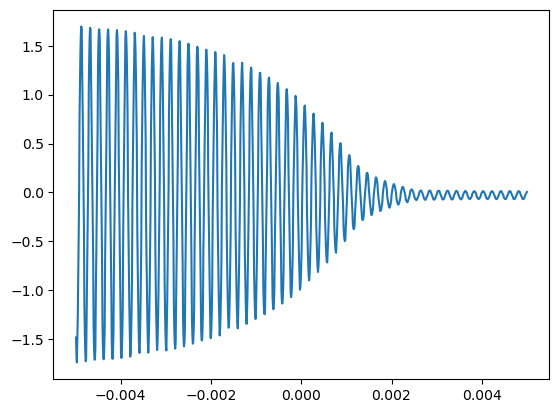

In [ ]:
plt.plot(time, Vin)


[ 10  30  50  70  90 111 132 152 172 192 213 233 253 273 293 314 334]


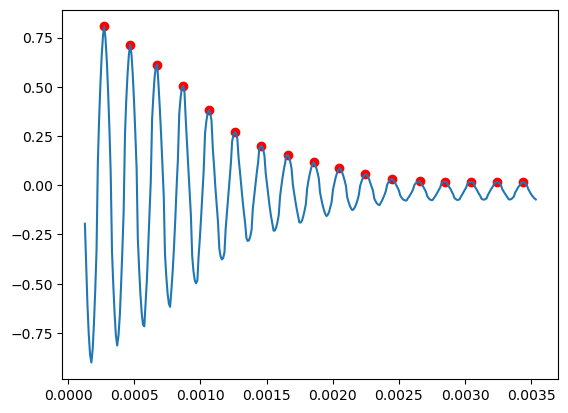

In [ ]:
from scipy.signal import find_peaks

peaks = find_peaks(Vin_cropped, height=None)
plt.plot(time_cropped, Vin_cropped)
print(peaks[0])

x = time_cropped[peaks[0]]
y = Vin_cropped[peaks[0]]
plt.scatter(x, y, color ='r')


In [217]:
def model_bis(t,alpha,A):
    return A*np.exp(alpha*t)

popt, pcov = curve_fit(model_bis, x,y, p0 = [-800,1])
alpha_bis,A = popt
print(alpha_bis)

Q = -1/(np.sqrt(L*C)*2*alpha_bis)
print(Q)


-1167.953622572827
13.53768505466148


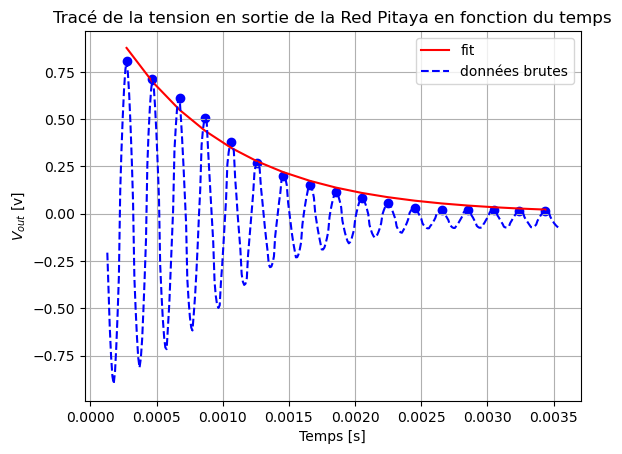

In [223]:
#plt.plot(time_cropped, model(time_cropped, *p0))
plt.title('Tracé de la tension en sortie de la Red Pitaya en fonction du temps')
plt.scatter(x, y, color ='b')
plt.plot(x,model_bis(x,*popt), color ='r', label ='fit')
plt.plot(time_cropped, Vin_cropped, color ='b', linestyle ='--', label ='données brutes')
plt.legend()
plt.xlabel("Temps [s]")
plt.ylabel("$V_{out}$ [v]")
plt.grid()
plt.show()
